In [1]:
using LinearAlgebra, Statistics
using Random
using Plots
using Printf

In [2]:
# Евклидова норма ошибки решения
function err(x_calc, x_true)
    return norm(x_calc - x_true)
end

# Степень диагонального преобладания:
# для каждой строки считаем |a_ii| - сумму модулей вне диагонали,
# берём МИНИМУМ по строкам. Если > 0, то преобладание есть.
function dominance_degree(A)
    n = size(A,1)
    dmin = +Inf
    for i in 1:n
        s = 0.0
        for j in 1:n
            if j != i
                s += abs(A[i,j])
            end
        end
        val = abs(A[i,i]) - s
        if val < dmin
            dmin = val
        end
    end
    return dmin
end


dominance_degree (generic function with 1 method)

In [3]:
function back_substitution(U, y)
    n = size(U,1)
    x = zeros(Float64, n)
    for i in n:-1:1
        s = 0.0
        for j in i+1:n
            s += U[i,j]*x[j]
        end
        x[i] = (y[i] - s) / U[i,i]
    end
    return x
end


back_substitution (generic function with 1 method)

In [4]:
# Без перестановок (ломается на "плохих" матрицах — это нормально для сравнения)
function gauss_no_pivot(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    for k in 1:n-1
        # если A[k,k] ≈ 0, метод может упасть — оставим как есть
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end
    return back_substitution(A, b)
end

gauss_no_pivot (generic function with 1 method)

In [5]:
# Перестановки по строкам
function gauss_rows(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    for k in 1:n-1
        # ищем строку с максимальным |элементом| в столбце k (ниже диагонали)
        imax = argmax(abs.(A[k:n,k])) + k - 1
        # меняем строки местами
        if imax != k
            A[k,:], A[imax,:] = A[imax,:], A[k,:]
            b[k], b[imax] = b[imax], b[k]
        end

        # исключение
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    return back_substitution(A, b)
end

gauss_rows (generic function with 1 method)

In [6]:
# Перестановки по столбцам
function gauss_cols(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    p = collect(1:n)

    for k in 1:n-1
        jmax = argmax(abs.(A[k, k:n])) + k - 1
        # меняем столбцы местами + отмечаем перестановку
        if jmax != k
            A[:,[k,jmax]] = A[:,[jmax,k]]
            p[k], p[jmax] = p[jmax], p[k]
        end

        # исключение
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    xperm = back_substitution(A, b)

    # возвращаем порядок компонент x (по перестановке столбцов)
    x = similar(xperm)
    for j in 1:n
        x[p[j]] = xperm[j]
    end
    return x
end

gauss_cols (generic function with 1 method)

In [7]:
# Перестановки по строкам + столбцам
function gauss_full(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    p = collect(1:n)   # перестановка столбцов

    for k in 1:n-1
        # ищем максимум по модулю в подматрице k:n, k:n
        imax, jmax = k, k
        maxval = 0.0
        for i in k:n
            for j in k:n
                if abs(A[i,j]) > maxval
                    maxval = abs(A[i,j])
                    imax, jmax = i, j
                end
            end
        end

        # меняем строки
        if imax != k
            A[k,:], A[imax,:] = A[imax,:], A[k,:]
            b[k], b[imax] = b[imax], b[k]
        end
        # меняем столбцы (и помним перестановку)
        if jmax != k
            A[:,[k,jmax]] = A[:,[jmax,k]]
            p[k], p[jmax] = p[jmax], p[k]
        end

        # исключение
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    xperm = back_substitution(A, b)

    x = similar(xperm)
    for j in 1:n
        x[p[j]] = xperm[j]
    end
    return x
end

gauss_full (generic function with 1 method)

In [8]:
function make_matrix_with_degree(n, α; seed=1)
    Random.seed!(seed)
    A = randn(n,n)
    # занулим диагональ перед настройкой
    for i in 1:n
        A[i,i] = 0.0
    end
    # выставим диагональ под нужную степень
    for i in 1:n
        s = 0.0
        for j in 1:n
            if j != i
                s += abs(A[i,j])
            end
        end
        # хотим: |a_ii| - s = α  ->  |a_ii| = s + α
        # добавим случайный знак, чтобы матрицы были разнообразнее
        aii = s + α
        if rand() < 0.5
            aii = -aii
        end
        A[i,i] = aii
    end
    return A
end

make_matrix_with_degree (generic function with 1 method)

In [9]:
function run_tests(n; degrees=-200.0:50.0:400.0, repeats=5, base_seed=1234)
    solvers = [
        "без перестановок" => gauss_no_pivot,
        "по строкам"       => gauss_rows,
        "по столбцам"      => gauss_cols,
        "строки+столбцы"   => gauss_full,
        "библиотека (\\)"  => (A,b)->A\b,
    ]
    errs = Dict(name => Union{Missing,Float64}[] for (name, _) in solvers)

    for dd in degrees
        A = make_matrix_with_degree(n, dd)
        for (name, solver) in solvers
            vals = Float64[]
            for r in 1:repeats
                rng = MersenneTwister(base_seed + r + round(Int, 10*dd))
                x_true = rand(rng, n)
                b = A * x_true
                val = try
                    norm(solver(A, b) - x_true)
                catch
                    NaN
                end
                if isfinite(val)
                    push!(vals, val)
                end
            end
            push!(errs[name], isempty(vals) ? missing : median(vals))
        end
    end
    return collect(degrees), errs
end

run_tests (generic function with 1 method)

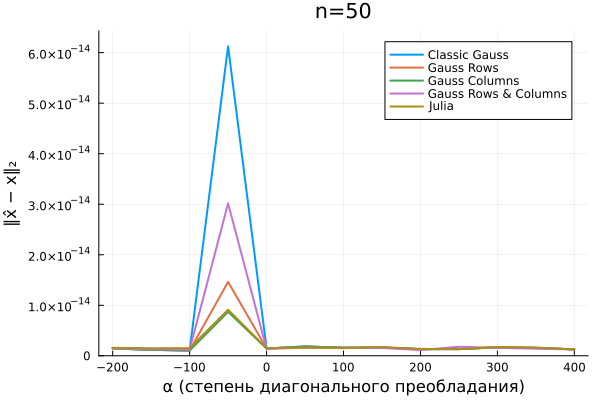

In [10]:
n = 50
degrees = collect(-200.0:50.0:400.0)
degrees, errs = run_tests(n; degrees=degrees)

order  = ["без перестановок","по строкам","по столбцам","строки+столбцы","библиотека (\\)"]
labels = ["Classic Gauss","Gauss Rows","Gauss Columns","Gauss Rows & Columns","Julia \\ (LU, PP)"]

allvals = [v for name in order for v in errs[name] if v !== missing && isfinite(v)]
ymax = isempty(allvals) ? 1.0 : maximum(allvals)

plt = plot(
    title = @sprintf("n=%d", n),
    xlabel = "α (степень диагонального преобладания)",
    ylabel = "‖x̂ − x‖₂",
    legend = :topright,
    grid = true,
    yformatter = :scientific,
    lw = 2,
    marker = false,
    ylim = (0, 1.05*ymax),
)

for (name, label) in zip(order, labels)
    plot!(degrees, errs[name], label = label, lw = 2)
end

display(plt)

Что говорить на защите (кратко)

Степень диагонального преобладания считаем как минимум по строкам: если > 0, то условие выполняется.

Без перестановок метод даёт большие ошибки/ломается при α ≤ 0.

Перестановка по строкам спасает многие случаи; по столбцам — тоже.

Полный выбор (строки+столбцы) самый устойчивый.

Библиотечное \ соответствует устойчивой LU-факторизации с перестановками — используем как «истину» для сравнения.

In [11]:
using LinearAlgebra, Random, Printf

# 5. Оценка округления (простая оценка сверху)
function rounding_error(A::AbstractMatrix, b::AbstractVector, x::AbstractVector)
    r = A*x - b
    rnorm = norm(r)
    est = try
        # очень грубая оценка сверху на рост ошибки из-за округления
        cond(A) * eps(Float64) * (norm(A)*norm(x) + norm(b)) / max(norm(b), eps(Float64))
    catch
        NaN
    end
    return est, rnorm
end

# Синтетические возмущения ΔA, Δb с заданным относительным уровнем (по норме)
function make_perturbations(A::AbstractMatrix, b::AbstractVector; level=1e-12, rng=MersenneTwister(42))
    ΔA_raw = rand(rng, size(A)...) .- 0.5
    Δb_raw = rand(rng, length(b)) .- 0.5

    # Нормируем и масштабируем под заданный уровень относительно ||A|| и ||b||
    nA = norm(ΔA_raw); nB = norm(Δb_raw)
    ΔA = (nA > 0 ? ΔA_raw / nA : zero(ΔA_raw)) * (level * max(norm(A), eps(Float64)))
    Δb = (nB > 0 ? Δb_raw / nB : zero(Δb_raw)) * (level * max(norm(b), eps(Float64)))
    return ΔA, Δb
end

# Теоретическая граница и фактическая ошибка от возмущения
function perturbation_error(A::AbstractMatrix, b::AbstractVector, x::AbstractVector,
                            ΔA::AbstractMatrix, Δb::AbstractVector)
    x_pert = (A + ΔA) \ (b + Δb)
    abs_err = norm(x_pert - x)

    relA = norm(ΔA) / max(norm(A), eps(Float64))
    relb = norm(Δb) / max(norm(b), eps(Float64))
    κ = try cond(A) catch; Inf end

    # простая оценка сверху (без знаменателя 1 - κ*relA)
    bound = κ * (relA + relb) * max(norm(x), eps(Float64))
    return bound, abs_err
end

# Отчёт по одному методу
function error_report(A, b, solver, x_true; name="метод",
                      ΔA=zeros(eltype(A), size(A)), Δb=zeros(eltype(b), length(b)))
    x = try
        solver(A, b)
    catch
        fill(NaN, size(b))
    end

    abs_err = norm(x - x_true)
    rel_err = abs_err / max(norm(x_true), eps(Float64))
    round_est, rnorm = rounding_error(A, b, x)
    bound, actual = perturbation_error(A, b, x, ΔA, Δb)
    κ = try cond(A) catch; NaN end

    @printf("=== %s ===\n", name)
    @printf("Абсолютная погрешность: %.4e\n", abs_err)
    @printf("Относительная погрешность: %.4e\n", rel_err)
    @printf("Норма невязки: %.4e\n", rnorm)
    @printf("Оценка погрешности округления: %.4e\n", round_est)
    @printf("Теоретическая граница возмущения: %.4e\n", bound)
    @printf("Фактическое возмущение: %.4e\n", actual)
    @printf("Число обусловленности матрицы: %.3f\n\n", κ)

    return (abs_err=abs_err, rel_err=rel_err, rnorm=rnorm,
            round_est=round_est, bound=bound, actual=actual, cond=κ)
end

error_report (generic function with 1 method)

In [15]:
n = 50
A = make_matrix_with_degree(n, 0.5; seed=54363262)
x_true = randn(n)
b = A * x_true

rng = MersenneTwister(2025)
ΔA, Δb = make_perturbations(A, b; level=1e-12, rng=rng)

error_report(A, b, gauss_no_pivot, x_true; name="без перестановок",  ΔA=ΔA, Δb=Δb)
error_report(A, b, gauss_rows,     x_true; name="по строкам",        ΔA=ΔA, Δb=Δb)
error_report(A, b, gauss_cols,     x_true; name="по столбцам",       ΔA=ΔA, Δb=Δb)
error_report(A, b, gauss_full,     x_true; name="строки+столбцы",    ΔA=ΔA, Δb=Δb)
error_report(A, b, (A,b)->A\b,     x_true; name="библиотека (\\)",   ΔA=ΔA, Δb=Δb)


=== без перестановок ===
Абсолютная погрешность: 2.6719e-15
Относительная погрешность: 3.5729e-16
Норма невязки: 9.9180e-14
Оценка погрешности округления: 3.1770e-15
Теоретическая граница возмущения: 2.7454e-11
Фактическое возмущение: 1.0290e-11
Число обусловленности матрицы: 1.836

=== по строкам ===
Абсолютная погрешность: 2.6719e-15
Относительная погрешность: 3.5729e-16
Норма невязки: 9.9180e-14
Оценка погрешности округления: 3.1770e-15
Теоретическая граница возмущения: 2.7454e-11
Фактическое возмущение: 1.0290e-11
Число обусловленности матрицы: 1.836

=== по столбцам ===
Абсолютная погрешность: 2.6719e-15
Относительная погрешность: 3.5729e-16
Норма невязки: 9.9180e-14
Оценка погрешности округления: 3.1770e-15
Теоретическая граница возмущения: 2.7454e-11
Фактическое возмущение: 1.0290e-11
Число обусловленности матрицы: 1.836

=== строки+столбцы ===
Абсолютная погрешность: 2.8259e-15
Относительная погрешность: 3.7788e-16
Норма невязки: 9.1364e-14
Оценка погрешности округления: 3.1770

(abs_err = 2.833731196750832e-15, rel_err = 3.789364599198203e-16, rnorm = 1.0886058042665268e-13, round_est = 3.1770375572275204e-15, bound = 2.745434003582107e-11, actual = 1.0289926682528385e-11, cond = 1.8356452500748246)

Решение системы линейных уравнений Ax = b различными методами Гаусса
Генерация случайных матриц и векторов...

Сгенерированная матрица A (4×4):


4×4 Matrix{Float64}:
 0.0760941  1.04717  4.97639   2.23332
 3.89952    2.2894   3.09028   3.99721
 2.0962     1.65243  0.514651  1.06985
 4.40071    3.44463  3.0838    3.95556


Истинное решение x_true (4×1):


4-element Vector{Float64}:
 2.9479041511285784
 7.230479304070822
 1.9612215035287517
 4.414359159331294


Вектор b = A * x_true (4×1):


4-element Vector{Float64}:
 27.41434187215862
 51.75472257987502
 23.85927675992664
 61.388439807900625


Сравнение различных методов Гаусса:
--------------------------------------------------

Метод Гаусса без перестановок:
  === Комплексный анализ погрешностей ===
  Абсолютная погрешность: 5.137181770166879e-13
  Относительная погрешность: 5.595045303919093e-14
  Оценка погрешности округления: 1.4892436494079146e-13
  Теоретическая граница возмущения: 1.9144489405026477e-10
  Фактическое возмущение: 5.4502699229243575e-11
  Число обусловленности матрицы: 73.04730639093334

Метод Гаусса с перестановками по столбцам:
  === Комплексный анализ погрешностей ===
  Абсолютная погрешность: 7.856740153113387e-15
  Относительная погрешность: 8.556990790762238e-16
  Оценка погрешности округления: 1.4892436494078886e-13
  Теоретическая граница возмущения: 2.4599278817453297e-10
  Фактическое возмущение: 6.073947192095429e-11
  Число обусловленности матрицы: 73.04730639093334

Метод Гаусса с перестановками по строкам:
  === Комплексный анализ погрешностей ===
  Абсолютная погрешность: 1.062338991344

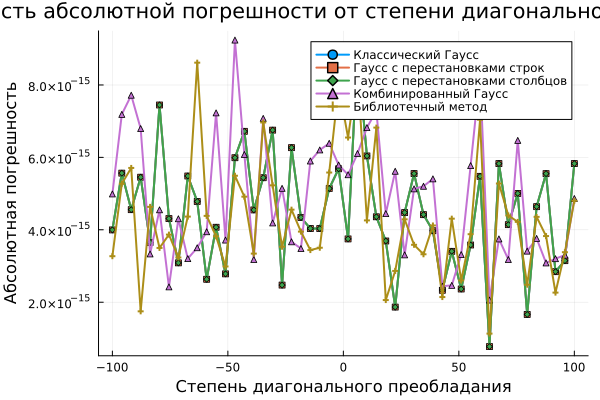

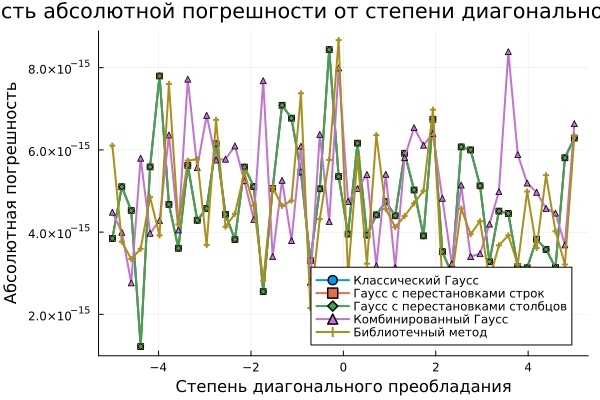

In [1]:
using LinearAlgebra
using Plots
using Random

function check_diagonal_dominance(A::Matrix{Float64})
    n = size(A, 1)
    
    min_dominance = Inf
    is_dominant = true
    
    for i in 1:n
        diagonal_element = abs(A[i, i])
        row_sum = 0.0
        
        for j in 1:n
            if i != j
                row_sum += abs(A[i, j])
            end
        end
        
        dominance = diagonal_element - row_sum
        
        if dominance < min_dominance
            min_dominance = dominance
        end
        
        if dominance <= 0
            is_dominant = false
        end
    end
    
    if !is_dominant
        min_dominance = min(min_dominance, 0.0)
    end
    
    return is_dominant, min_dominance
end

function gauss_solve_vector(A::Matrix{Float64}, b::Vector{Float64})
    n = length(b)
    
    M = copy(A)
    r = copy(b)

    for i in 1:n
        if M[i, i] == 0
            throw(ErrorException("Нулевой диагональный элемент в строке $i, метод без перестановок не применим."))
        end

        for k in (i+1):n
            if M[k, i] != 0
                factor = M[k, i] / M[i, i]
                for j in i:n
                    M[k, j] -= factor * M[i, j]
                end
                r[k] -= factor * r[i]
            end
        end
    end

    x = zeros(n)
    
    for i in n:-1:1
        x[i] = r[i]
        for k in (i+1):n
            x[i] -= M[i, k] * x[k]
        end
        if M[i, i] == 0
            throw(ErrorException("Матрица вырождена."))
        end
        x[i] /= M[i, i]
    end

    return x
end

function gauss_solve_vector_column_pivot(A::Matrix{Float64}, b::Vector{Float64})
    n = length(b)
    
    M = copy(A)
    r = copy(b)
    
    col_perm = collect(1:n)

    for i in 1:n
        max_col = i
        max_val = abs(M[i, i])
        
        for j in (i+1):n
            if abs(M[i, j]) > max_val
                max_val = abs(M[i, j])
                max_col = j
            end
        end
        
        if max_col != i
            for k in 1:n
                M[k, i], M[k, max_col] = M[k, max_col], M[k, i]
            end
            col_perm[i], col_perm[max_col] = col_perm[max_col], col_perm[i]
        end
        
        if abs(M[i, i]) < 1e-12
            throw(ErrorException("Матрица вырождена или близка к вырожденной."))
        end

        for k in (i+1):n
            if M[k, i] != 0
                factor = M[k, i] / M[i, i]
                for j in i:n
                    M[k, j] -= factor * M[i, j]
                end
                r[k] -= factor * r[i]
            end
        end
    end

    x_temp = zeros(n)
    
    for i in n:-1:1
        x_temp[i] = r[i]
        for k in (i+1):n
            x_temp[i] -= M[i, k] * x_temp[k]
        end
        x_temp[i] /= M[i, i]
    end

    x = zeros(n)
    for i in 1:n
        x[col_perm[i]] = x_temp[i]
    end

    return x
end

function gauss_solve_vector_row_pivot(A::Matrix{Float64}, b::Vector{Float64})
    n = length(b)
    
    M = copy(A)
    r = copy(b)

    for i in 1:n
        max_row = i
        max_val = abs(M[i, i])
        
        for k in (i+1):n
            if abs(M[k, i]) > max_val
                max_val = abs(M[k, i])
                max_row = k
            end
        end
        
        if max_row != i
            for j in 1:n
                M[i, j], M[max_row, j] = M[max_row, j], M[i, j]
            end
            r[i], r[max_row] = r[max_row], r[i]
        end
        
        if abs(M[i, i]) < 1e-12
            throw(ErrorException("Матрица вырождена или близка к вырожденной."))
        end

        for k in (i+1):n
            if M[k, i] != 0
                factor = M[k, i] / M[i, i]
                for j in i:n
                    M[k, j] -= factor * M[i, j]
                end
                r[k] -= factor * r[i]
            end
        end
    end

    x = zeros(n)
    
    for i in n:-1:1
        x[i] = r[i]
        for k in (i+1):n
            x[i] -= M[i, k] * x[k]
        end
        x[i] /= M[i, i]
    end

    return x
end

function gauss_solve_vector_combined(A::Matrix{Float64}, b::Vector{Float64})
    n = length(b)
    
    M = copy(A)
    r = copy(b)
    
    col_perm = collect(1:n)

    for i in 1:n
        max_row = i
        max_col = i
        max_val = abs(M[i, i])
        
        for k in i:n
            for j in i:n
                if abs(M[k, j]) > max_val
                    max_val = abs(M[k, j])
                    max_row = k
                    max_col = j
                end
            end
        end
        
        if max_row != i
            for j in 1:n
                M[i, j], M[max_row, j] = M[max_row, j], M[i, j]
            end
            r[i], r[max_row] = r[max_row], r[i]
        end
        
        if max_col != i
            for k in 1:n
                M[k, i], M[k, max_col] = M[k, max_col], M[k, i]
            end
            col_perm[i], col_perm[max_col] = col_perm[max_col], col_perm[i]
        end
        
        if abs(M[i, i]) < 1e-12
            throw(ErrorException("Матрица вырождена или близка к вырожденной."))
        end

        for k in (i+1):n
            if M[k, i] != 0
                factor = M[k, i] / M[i, i]
                for j in i:n
                    M[k, j] -= factor * M[i, j]
                end
                r[k] -= factor * r[i]
            end
        end
    end

    x_temp = zeros(n)
    
    for i in n:-1:1
        x_temp[i] = r[i]
        for k in (i+1):n
            x_temp[i] -= M[i, k] * x_temp[k]
        end
        x_temp[i] /= M[i, i]
    end

    x = zeros(n)
    for i in 1:n
        x[col_perm[i]] = x_temp[i]
    end

    return x
end

function calculate_errors_vector(A::Matrix{Float64}, b::Vector{Float64}, x::Vector{Float64})
    residual = A * x - b
    
    absolute_error = norm(residual)
    
    b_norm = norm(b)
    if b_norm == 0
        relative_error = absolute_error
    else
        relative_error = absolute_error / b_norm
    end
    
    return absolute_error, relative_error
end

function calculate_rounding_error(A::Matrix{Float64}, b::Vector{Float64}, x::Vector{Float64})
    n = size(A, 1)
    
    residual = A * x - b
    
    try
        cond_A = cond(A)
        eps_m = eps(Float64)
        rounding_error_estimate = cond_A * eps_m * norm(x)
        residual_error = norm(residual)
        
        return rounding_error_estimate, residual_error
    catch
        return NaN, norm(residual)
    end
end

function calculate_perturbation_error(A::Matrix{Float64}, b::Vector{Float64}, x::Vector{Float64}, 
                                    delta_A::Matrix{Float64}, delta_b::Vector{Float64})
    n = size(A, 1)
    
    try
        cond_A = cond(A)
        
        rel_pert_A = norm(delta_A) / norm(A)
        rel_pert_b = norm(delta_b) / norm(b)
        
        denominator = 1 - cond_A * rel_pert_A
        
        if denominator > 0
            theoretical_perturbation_bound = cond_A * (rel_pert_A + rel_pert_b) / denominator
            
            A_pert = A + delta_A
            b_pert = b + delta_b
            
            x_pert = A_pert \ b_pert
            actual_perturbation = norm(x_pert - x) / norm(x)
            
            return theoretical_perturbation_bound, actual_perturbation
        else
            return Inf, NaN
        end
    catch
        return NaN, NaN
    end
end

function comprehensive_error_analysis(A::Matrix{Float64}, b::Vector{Float64}, x_computed::Vector{Float64}, 
                                   x_true::Vector{Float64})
    println("  === Комплексный анализ погрешностей ===")
    
    diff = x_computed - x_true
    abs_error = norm(diff)
    rel_error = abs_error / norm(x_true)
    
    println("  Абсолютная погрешность: ", abs_error)
    println("  Относительная погрешность: ", rel_error)
    
    rounding_estimate, residual_error = calculate_rounding_error(A, b, x_computed)
    println("  Оценка погрешности округления: ", rounding_estimate)
    
    perturbation_level = 1e-12
    delta_A = (rand(Float64, size(A)) .- 0.5) * 2 * perturbation_level * norm(A)
    delta_b = (rand(Float64, size(b)) .- 0.5) * 2 * perturbation_level * norm(b)
    
    theoretical_bound, actual_perturbation = calculate_perturbation_error(A, b, x_computed, delta_A, delta_b)
    println("  Теоретическая граница возмущения: ", theoretical_bound)
    println("  Фактическое возмущение: ", actual_perturbation)
    
    try
        cond_A = cond(A)
        println("  Число обусловленности матрицы: ", cond_A)
    catch
        println("  Число обусловленности: не удалось вычислить")
    end
    
    return abs_error, rel_error, rounding_estimate, residual_error, theoretical_bound, actual_perturbation
end

function generate_matrix_with_dominance(n::Int, dominance_level::Float64, scale::Float64 = 10.0)
    A = rand(Float64, n, n) * scale
    
    for i in 1:n
        row_sum = sum(abs, A[i, :]) - abs(A[i, i])
        target_diagonal = row_sum + max(dominance_level, 1e-10)
        if target_diagonal > 0
            A[i, i] = sign(A[i, i]) * target_diagonal
        else
            A[i, i] = sign(A[i, i]) * (abs(A[i, i]) + 1.0)
        end
    end
    
    return A
end

function generate_random_vector(n::Int, scale::Float64 = 10.0)
    return rand(Float64, n) * scale
end

function run_experiment(start, stop)
    n = 10
    num_points = 50
    
    dominance_levels = range(start, stop, length=num_points)
    
    errors_no_pivot = zeros(num_points)
    errors_col_pivot = zeros(num_points)
    errors_row_pivot = zeros(num_points)
    errors_combined = zeros(num_points)
    errors_builtin = zeros(num_points)
    
    for (idx, dominance) in enumerate(dominance_levels)
        A = generate_matrix_with_dominance(n, dominance, 10.0)
        x_true = generate_random_vector(n)
        b = A * x_true
        
        _, actual_dominance = check_diagonal_dominance(A)
        
        try
            x_no_pivot = gauss_solve_vector(A, b)
            errors_no_pivot[idx] = norm(x_true - x_no_pivot)
        catch
            errors_no_pivot[idx] = NaN
        end
        
        try
            x_col_pivot = gauss_solve_vector_column_pivot(A, b)
            errors_col_pivot[idx] = norm(x_true - x_col_pivot)
        catch
            errors_col_pivot[idx] = NaN
        end
        
        try
            x_row_pivot = gauss_solve_vector_row_pivot(A, b)
            errors_row_pivot[idx] = norm(x_true - x_row_pivot)
        catch
            errors_row_pivot[idx] = NaN
        end
        
        try
            x_combined = gauss_solve_vector_combined(A, b)
            errors_combined[idx] = norm(x_true - x_combined)
        catch
            errors_combined[idx] = NaN
        end
        
        try
            x_builtin = A \ b
            errors_builtin[idx] = norm(x_true - x_builtin)
        catch
            errors_builtin[idx] = NaN
        end
    end
    
    p = plot(dominance_levels, errors_no_pivot, 
             label="Классический Гаусс", linewidth=2, marker=:circle, markersize=3)
    plot!(p, dominance_levels, errors_row_pivot, 
          label="Гаусс с перестановками строк", linewidth=2, marker=:square, markersize=3)
    plot!(p, dominance_levels, errors_col_pivot, 
          label="Гаусс с перестановками столбцов", linewidth=2, marker=:diamond, markersize=3)
    plot!(p, dominance_levels, errors_combined, 
          label="Комбинированный Гаусс", linewidth=2, marker=:utriangle, markersize=3)
    plot!(p, dominance_levels, errors_builtin, 
          label="Библиотечный метод", linewidth=2, marker=:cross, markersize=3)
    
    xlabel!("Степень диагонального преобладания")
    ylabel!("Абсолютная погрешность")
    title!("Зависимость абсолютной погрешности от степени диагонального преобладания")
    
    
    return p
end



function main()
    println("Решение системы линейных уравнений Ax = b различными методами Гаусса")
    println("="^70)
    
    n = 4 
    
    println("Генерация случайных матриц и векторов...")
    A = rand(Float64, n, n) * 5.0
    x_true = rand(Float64, n) * 10.0
    
    b = A * x_true
    x_builtin = A \ b
    
    println("\nСгенерированная матрица A ($(n)×$(n)):")
    display(A)
    println("\nИстинное решение x_true ($(n)×1):")
    display(x_true)
    println("\nВектор b = A * x_true ($(n)×1):")
    display(b)
    
    methods = [
        ("Метод Гаусса без перестановок", gauss_solve_vector),
        ("Метод Гаусса с перестановками по столбцам", gauss_solve_vector_column_pivot),
        ("Метод Гаусса с перестановками по строкам", gauss_solve_vector_row_pivot),
        ("Комбинированный метод Гаусса", gauss_solve_vector_combined)
    ]
    
    println("\nСравнение различных методов Гаусса:")
    println("-" ^ 50)
    
    for (method_name, method_func) in methods
        try
            println("\n$method_name:")
            x_computed = method_func(A, b)
            
            comprehensive_error_analysis(A, b, x_computed, x_true)
            
        catch e
            println("  Ошибка: ", e)
        end
    end
    
    display(run_experiment(-100, 100))
    run_experiment(-5, 5)

end

main()